> # Testando os Pacotes do Qiskit 

[Video Tutorial](https://www.youtube.com/watch?v=ZItpTvwz4cc&list=PLhI5X1mNN8ghWTnnUjwjMXGosOJSeYTW4&index=2)




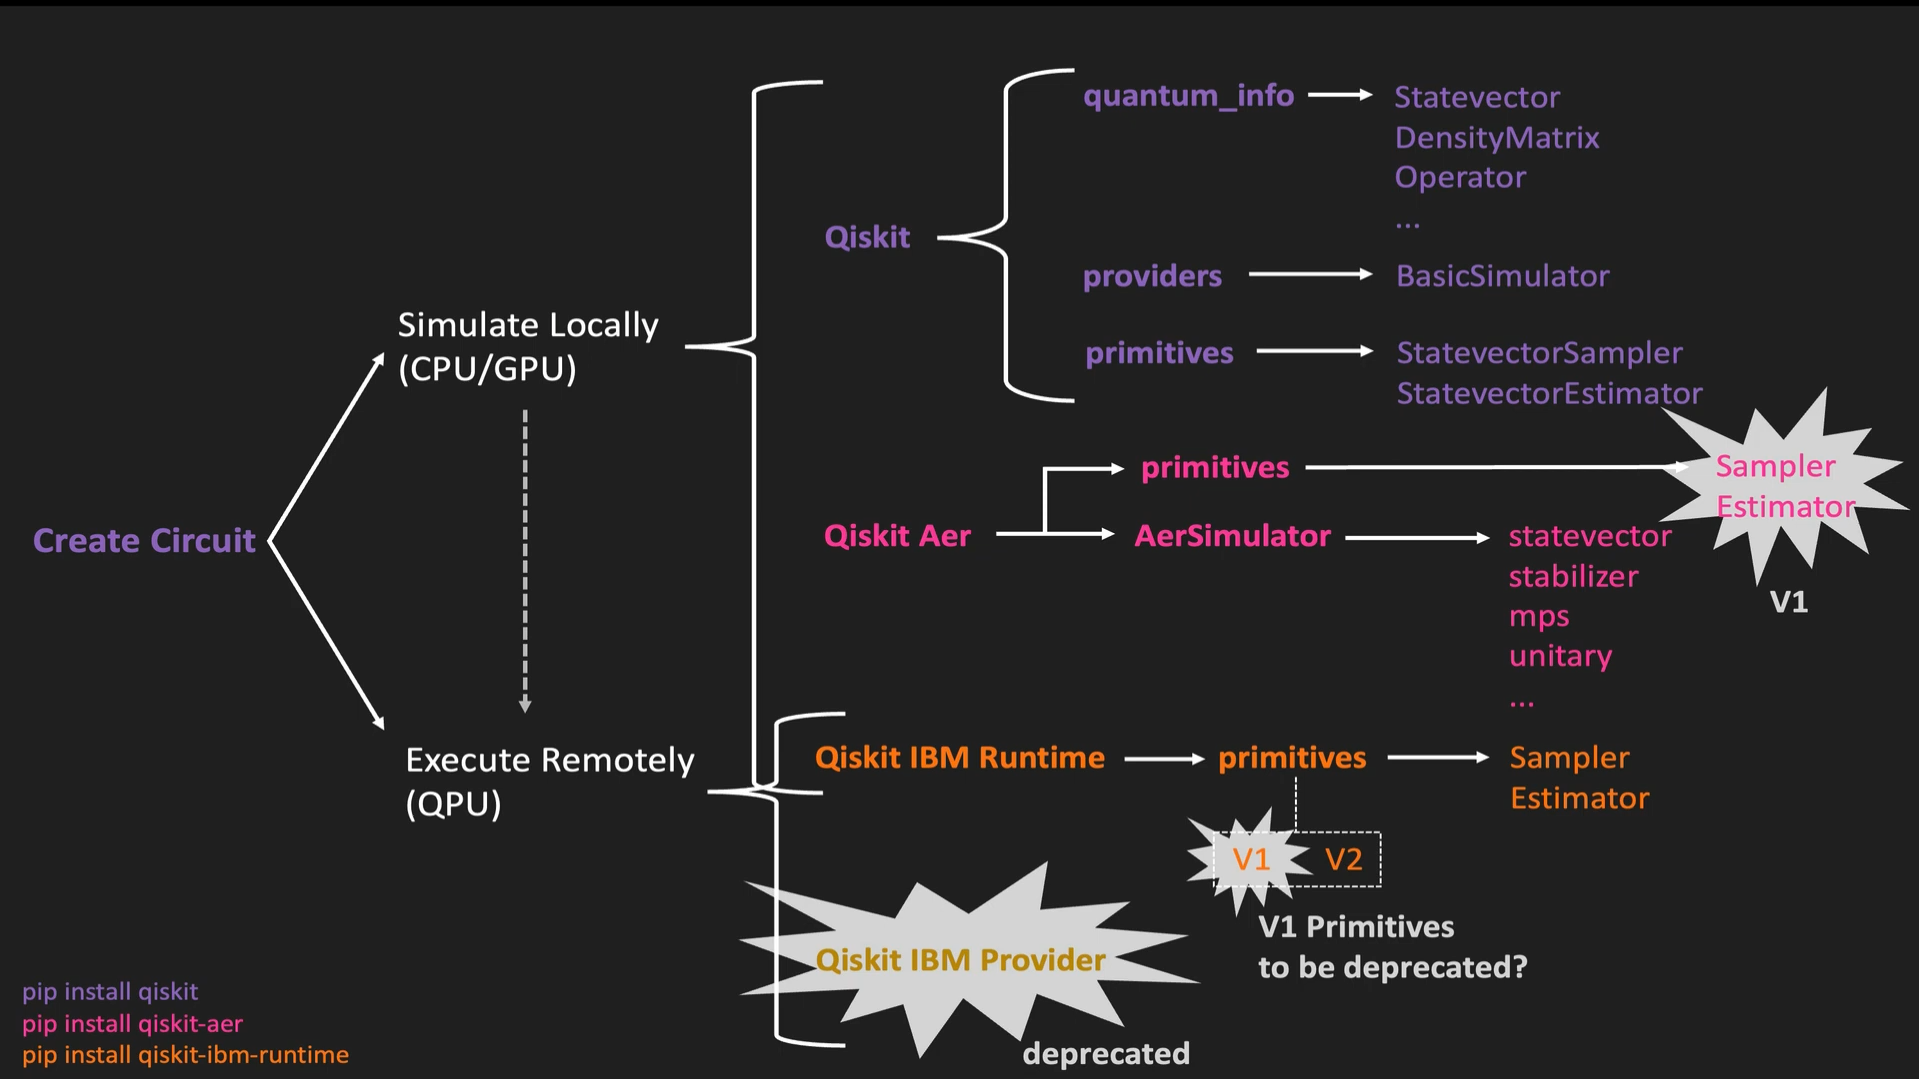


---

## 1. quantum_info - Qiskit Library

In [1]:
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    


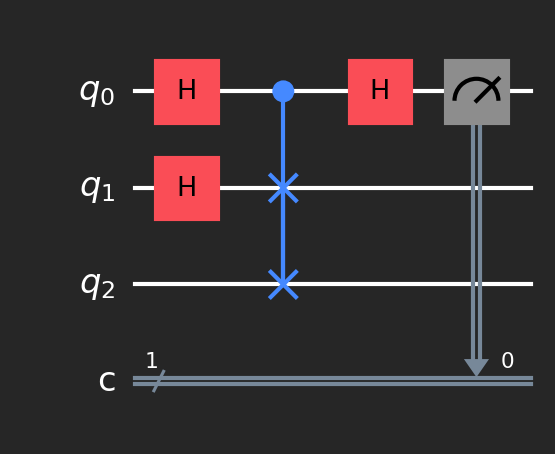

In [2]:
qc = QuantumCircuit(3, 1)
qc.h([0, 1])
qc.cswap(0, 1, 2)
qc.h(0)
qc.measure(0, 0)
qc.draw()


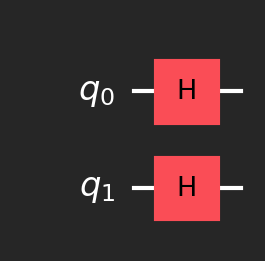

In [3]:
qc = QuantumCircuit(2)
qc.h([0, 1])
qc.draw()

In [4]:
ψ = qi.Statevector(qc)

ψ

<IPython.core.display.Latex object>

In [5]:
probs = ψ.probabilities()

print(probs)

[0.25 0.25 0.25 0.25]


In [6]:
counts = ψ.sample_counts(shots = 1024)
print(counts)

{'00': 265, '01': 234, '10': 261, '11': 264}


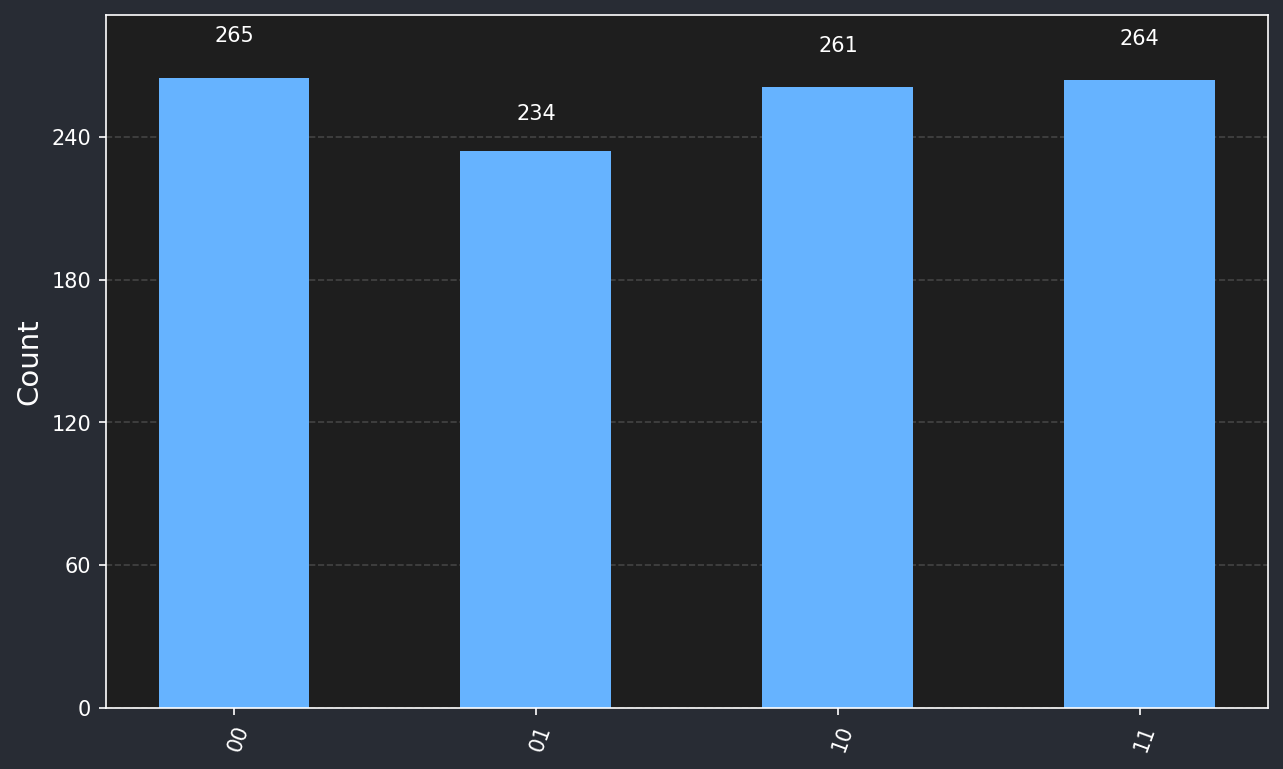

In [7]:
plot_histogram(counts, color = ['#66b3ff'])

In [8]:
Operator = qi.SparsePauliOp(['ZZ','XX','II'],[0.2,-0.3,0.4])
Operator.to_operator()

Operator([[ 0.6+0.j,  0. +0.j,  0. +0.j, -0.3+0.j],
          [ 0. +0.j,  0.2+0.j, -0.3+0.j,  0. +0.j],
          [ 0. +0.j, -0.3+0.j,  0.2+0.j,  0. +0.j],
          [-0.3+0.j,  0. +0.j,  0. +0.j,  0.6+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [10]:
Valor_esperado = ψ.expectation_value(Operator)
print(Valor_esperado)

(0.10000000000000003+0j)


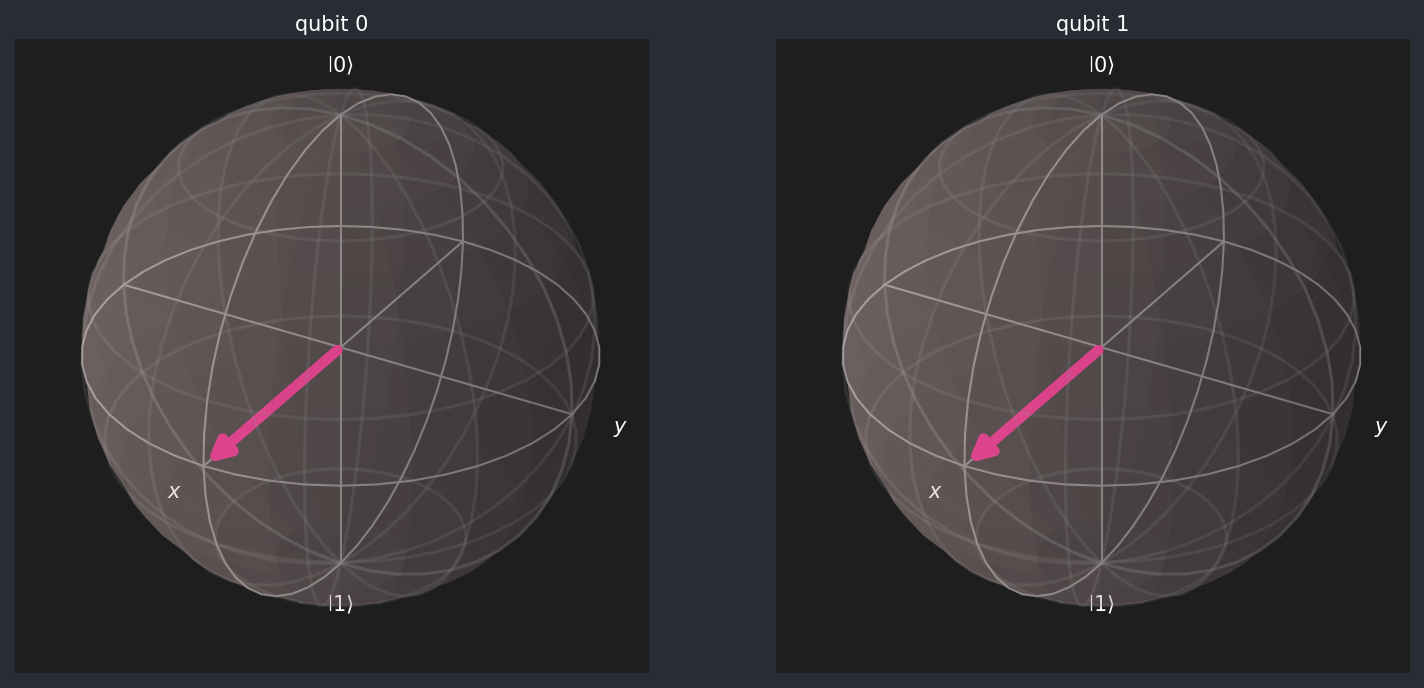

In [11]:
ψ.draw('bloch')

In [12]:
ρ = qi.DensityMatrix(qc)
ρ

<IPython.core.display.Latex object>

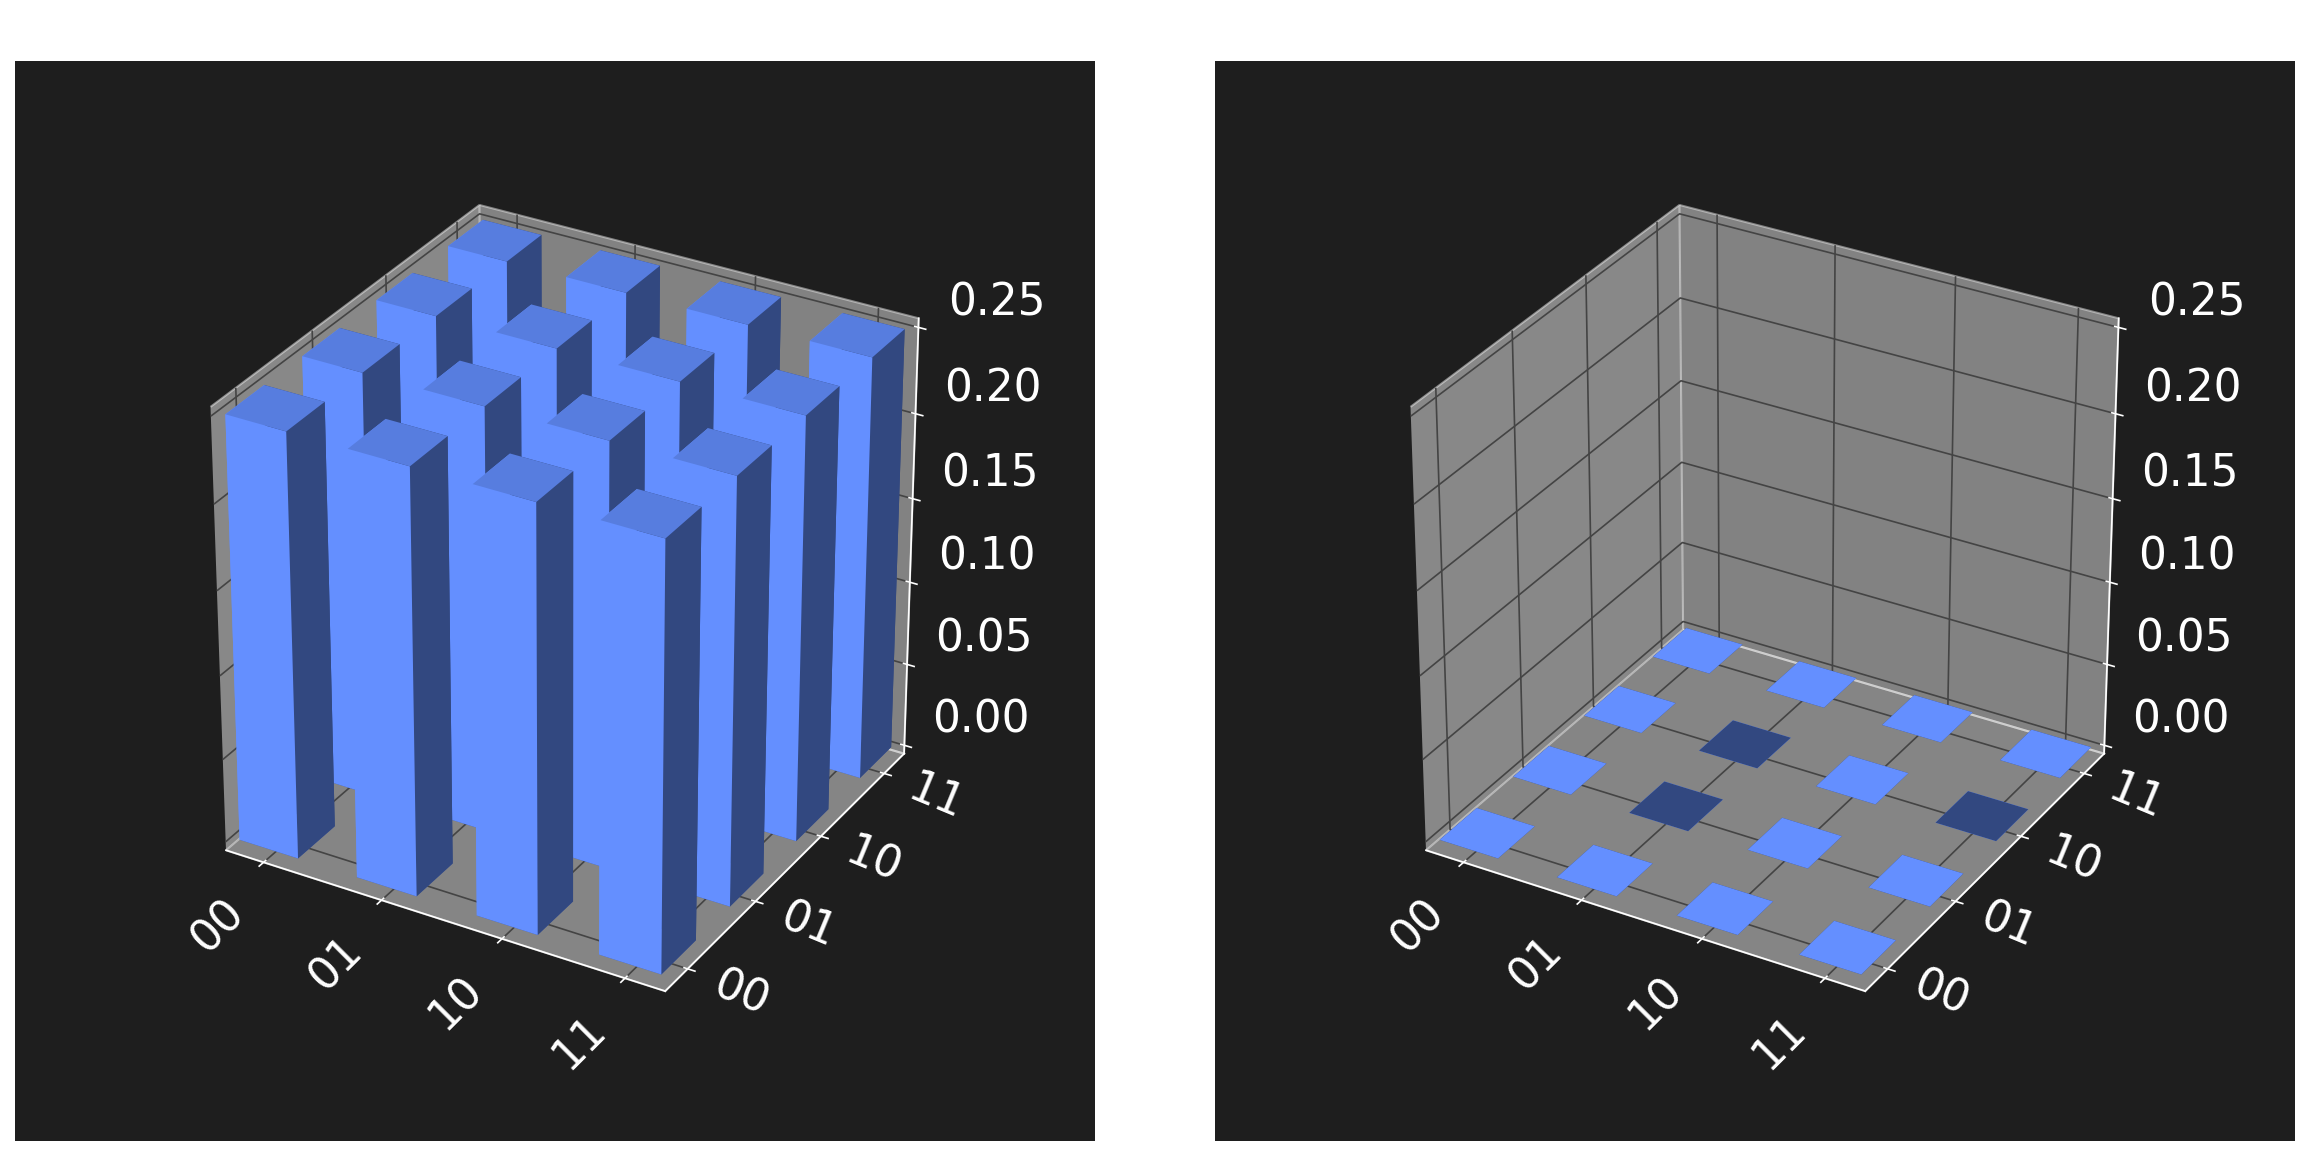

In [14]:
ρ.draw('city')

In [15]:
ρ1 = qi.partial_trace(ρ,[0])
ρ1

<IPython.core.display.Latex object>

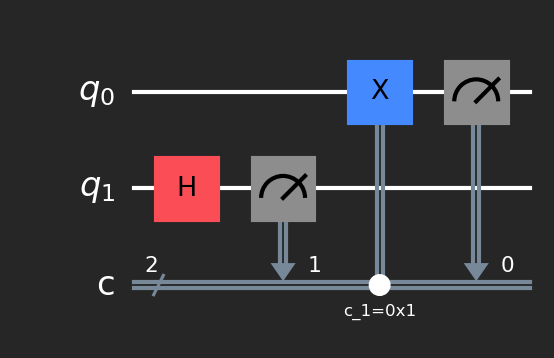

In [16]:
qc = QuantumCircuit(2,2)
qc.h(1)
qc.measure(1,1)
qc.x(0).c_if(1,1)
qc.measure(0,0)
qc.draw()

In [17]:
ψ = qi.Statevector(qc)
ψ

QiskitError: 'Cannot apply instruction with classical bits: measure'